# 10. Retention Analysis


> **Dataset note:** This project uses a synthetic OTT viewer-behaviour dataset for educational analysis.  
> **Hotstar is used only as the business case/scenario; the data is not claimed to be proprietary Hotstar data.**

**Allowed tools:** Python, NumPy, Pandas, Matplotlib, Seaborn.  
**Not used:** Scikit-learn, Plotly, Power BI, Tableau, machine learning, or statistical libraries beyond NumPy/Pandas.

## Process Performed
I analyzed retention-risk distribution, quantified high-risk episodes, compared cognitive load, identified high-risk shows, and profiled high-risk episode characteristics.

In [1]:
# PROCESS: Load the CSV into a Pandas DataFrame and verify that the file loaded correctly.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_PATH = "ott_viewer_dropoff_retention_us_v1.0.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,dialogue_density,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,high,5,39,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,low,8,55,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,high,7,46,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,medium,3,50,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,low,4,35,3,0,1,7,high,0,1,0.638,high,v1.0


## Retention Risk Distribution

In [2]:
# KERNEL-SAFE SETUP
# Keep plotting memory controlled while preserving the analysis.
import gc

MAX_PLOT_ROWS = 5000

def safe_sample(data, n=MAX_PLOT_ROWS, random_state=42):
    """Use the full data when small; otherwise use a reproducible sample for plotting."""
    return data if len(data) <= n else data.sample(n=n, random_state=random_state)

def finish_plot():
    """Render and release the current Matplotlib figure."""
    plt.tight_layout()
    plt.show()
    plt.close()
    gc.collect()

In [3]:
# PROCESS: Count category frequencies and percentages to understand how records are distributed.
retention_counts = df["retention_risk"].value_counts(dropna=False)
retention_pct = df["retention_risk"].value_counts(normalize=True, dropna=False).mul(100)

display(pd.DataFrame({
    "count": retention_counts,
    "percentage": retention_pct.round(2)
}))

,count,percentage
retention_risk,,
medium,27402,82.61
high,4804,14.48
low,965,2.91


## Percentage of High-Risk Episodes

In [4]:
# PROCESS: Perform this analysis step and inspect the resulting table/output before drawing conclusions.
high_risk_pct = (df["retention_risk"].astype(str).str.lower() == "high").mean() * 100
print(f"High retention-risk episodes: {high_risk_pct:.2f}%")

High retention-risk episodes: 14.48%


## Cognitive Load and Retention Risk

,retention_risk,episodes,avg_cognitive_load,median_cognitive_load,avg_watch_percentage,avg_drop_off_probability
0,high,4804,8.026,9.0,37.083,0.656
1,low,965,4.770,5.0,81.175,0.275
2,medium,27402,5.925,5.0,59.405,0.455


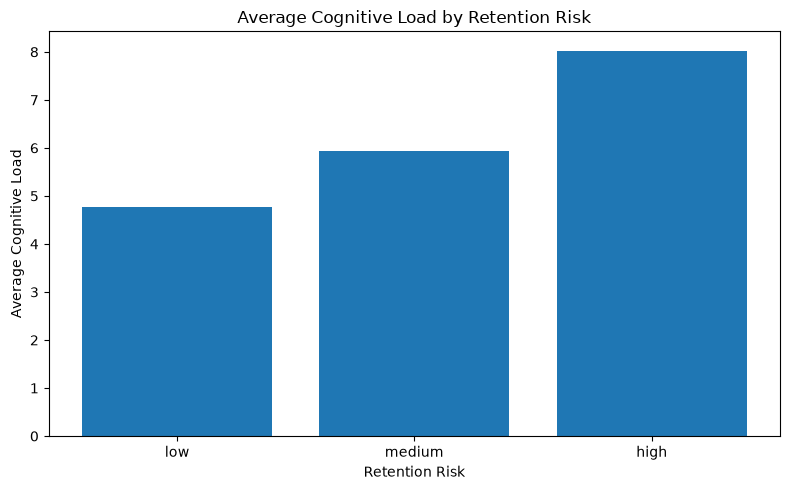

2917

In [5]:
# PROCESS: Compare average cognitive load across retention-risk categories.
# A compact Matplotlib bar chart is used here because it is lighter on memory
# and avoids plotting/deprecation warnings from large boxplots.

cognitive_retention = (
    df.groupby("retention_risk")
    .agg(
        episodes=("show_id", "size"),
        avg_cognitive_load=("cognitive_load", "mean"),
        median_cognitive_load=("cognitive_load", "median"),
        avg_watch_percentage=("avg_watch_percentage", "mean"),
        avg_drop_off_probability=("drop_off_probability", "mean")
    )
    .reset_index()
)

display(cognitive_retention.round(3))

plot_data = cognitive_retention.sort_values("avg_cognitive_load")

plt.figure(figsize=(8, 5))
plt.bar(
    plot_data["retention_risk"].astype(str),
    plot_data["avg_cognitive_load"]
)
plt.title("Average Cognitive Load by Retention Risk")
plt.xlabel("Retention Risk")
plt.ylabel("Average Cognitive Load")
plt.tight_layout()
plt.show()
plt.close()
gc.collect()

## Shows Containing High-Risk Episodes

In [6]:
# PROCESS: Perform this analysis step and inspect the resulting table/output before drawing conclusions.
high_risk_mask = df["retention_risk"].astype(str).str.lower().eq("high")

high_risk_shows = (
    df.assign(is_high_risk=high_risk_mask)
    .groupby(["show_id", "title"])
    .agg(
        episodes=("episode_number", "size"),
        high_risk_episodes=("is_high_risk", "sum"),
        avg_drop_off_probability=("drop_off_probability", "mean"),
        avg_watch_percentage=("avg_watch_percentage", "mean")
    )
    .reset_index()
)
high_risk_shows["high_risk_share_pct"] = (
    high_risk_shows["high_risk_episodes"] /
    high_risk_shows["episodes"] * 100
)

display(
    high_risk_shows.sort_values(
        ["high_risk_share_pct", "high_risk_episodes"],
        ascending=False
    ).head(20)
)

,show_id,title,episodes,high_risk_episodes,avg_drop_off_probability,avg_watch_percentage,high_risk_share_pct
337,85077,The Chosen,8,5,0.556500,47.000000,62.500000
475,281013,Dynamite Kiss,14,8,0.588857,45.142857,57.142857
457,259730,The Accident,10,5,0.541000,48.900000,50.000000
66,1508,Dancing with the Stars,8,4,0.519875,52.625000,50.000000
373,113962,Lioness,8,4,0.557250,46.625000,50.000000
463,271823,Playing Gracie Darling,6,3,0.562167,45.833333,50.000000
114,3034,Scene of the Crime,2,1,0.528500,47.000000,50.000000
227,46296,Spartacus,13,6,0.545385,49.076923,46.153846
428,226637,High Potential,13,6,0.550692,49.307692,46.153846
345,94605,Arcane,9,4,0.547111,51.222222,44.444444


## Characteristics of High-Risk Episodes

In [7]:
# PROCESS: Perform this analysis step and inspect the resulting table/output before drawing conclusions.
high_risk = df[high_risk_mask].copy()
other_risk = df[~high_risk_mask].copy()

compare_cols = [
    "episode_duration_min", "pacing_score", "hook_strength",
    "visual_intensity", "avg_watch_percentage", "pause_count",
    "rewind_count", "cognitive_load", "drop_off_probability"
]

comparison = pd.DataFrame({
    "high_risk_mean": high_risk[compare_cols].mean(),
    "other_mean": other_risk[compare_cols].mean()
})
comparison["difference"] = comparison["high_risk_mean"] - comparison["other_mean"]
display(comparison)

,high_risk_mean,other_mean,difference
episode_duration_min,37.658826,37.660979,-0.002153
pacing_score,4.160283,5.607502,-1.447219
hook_strength,4.244796,5.741989,-1.497193
visual_intensity,6.023730,6.007015,0.016715
avg_watch_percentage,37.082639,60.145909,-23.063270
pause_count,4.515820,2.863644,1.652176
rewind_count,2.013739,2.001763,0.011976
cognitive_load,8.026228,5.886065,2.140163
drop_off_probability,0.655519,0.448443,0.207076


### Interpretation Note
The outputs above describe patterns in the supplied **synthetic episode-level dataset**. They should support business hypotheses and content investigation, not be presented as causal proof or proprietary Hotstar findings.

## Key Interpretation

High-risk episodes make up about **14.48%** of records. Compared with other episodes, the High-risk group has much lower average watch completion (about **37.08% vs 60.15%**), higher cognitive load (about **8.03 vs 5.89**), more pauses, and higher average drop-off probability.

## High-Risk vs Other Episodes — Difference Profile

This comparison quantifies how high-retention-risk episodes differ from the rest of the dataset.  
It is descriptive EDA and should not be interpreted as proof that any variable causes retention risk.

In [8]:
high_risk_mask = (
    df["retention_risk"]
    .astype(str)
    .str.lower()
    .eq("high")
)

metrics = [
    "avg_watch_percentage",
    "episode_duration_min",
    "hook_strength",
    "pacing_score",
    "visual_intensity",
    "cognitive_load",
    "pause_count",
    "rewind_count",
    "drop_off_probability"
]

risk_profile = pd.DataFrame({
    "high_risk_mean": df.loc[high_risk_mask, metrics].mean(),
    "other_episodes_mean": df.loc[~high_risk_mask, metrics].mean()
})

risk_profile["absolute_difference"] = (
    risk_profile["high_risk_mean"]
    - risk_profile["other_episodes_mean"]
)

risk_profile["pct_difference_vs_other"] = np.where(
    risk_profile["other_episodes_mean"] != 0,
    risk_profile["absolute_difference"]
    / risk_profile["other_episodes_mean"]
    * 100,
    np.nan
)

display(
    risk_profile
    .sort_values("absolute_difference", ascending=False)
    .round(3)
)

,high_risk_mean,other_episodes_mean,absolute_difference,pct_difference_vs_other
cognitive_load,8.026,5.886,2.140,36.360
pause_count,4.516,2.864,1.652,57.695
drop_off_probability,0.656,0.448,0.207,46.177
visual_intensity,6.024,6.007,0.017,0.278
rewind_count,2.014,2.002,0.012,0.598
episode_duration_min,37.659,37.661,-0.002,-0.006
pacing_score,4.160,5.608,-1.447,-25.809
hook_strength,4.245,5.742,-1.497,-26.074
avg_watch_percentage,37.083,60.146,-23.063,-38.346


In [9]:
# KERNEL-SAFE CLEANUP
plt.close('all')
gc.collect()
print('Notebook cleanup complete.')

Notebook cleanup complete.
